# K-Nearest Neighbors (KNN) Classifier

### Titanic Survival Prediction

This notebook applies the **K-Nearest Neighbors (KNN)** classification algorithm to predict whether a passenger survived the Titanic disaster.


## Libraries

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report , confusion_matrix

## Load Dataset

In [31]:
df = sns.load_dataset ('titanic')

## Data preprocessing

In [32]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [33]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [34]:
df['age']=df['age'].fillna(df['age'].median())

In [35]:
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df['embarked'].describe()

count     891
unique      3
top         S
freq      646
Name: embarked, dtype: object

In [36]:
df=df.drop(columns=[
    'survived',
    'class' ,
    'who',           
    'adult_male',     
    'deck',          
    'embark_town'
])

In [37]:
df['family_size']=df['sibsp']+df['parch']

In [38]:
df['alive']=df['alive'].map({
    'no' : 0,
    'yes':1
})

Target: `alive` <br>
0 = Not Survived <br>
1 = Survived

In [39]:
df['alone']=df['alone'].astype(int)

In [40]:
df= pd.get_dummies(df, columns=['embarked'])

In [41]:
df= pd.get_dummies(df, columns=['sex'],drop_first=True)

In [42]:
boolean_columns = df.select_dtypes(include='bool').columns
df[boolean_columns] = df[boolean_columns].astype(int)

## EDA

Text(0.5, 1.0, 'Target balance: alive')

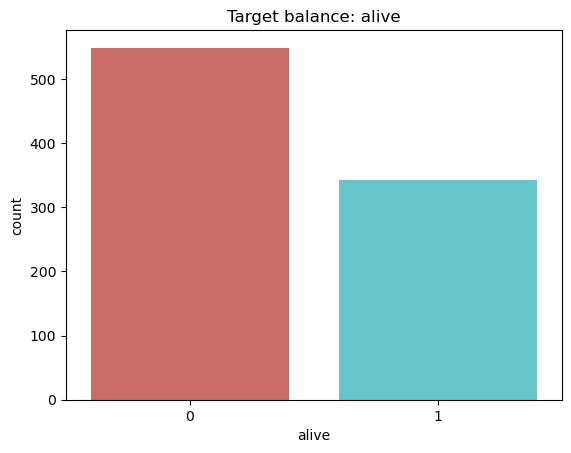

In [43]:
sns.countplot(
    x='alive',
    data=df,
    palette="hls"
    )

plt.title('Target balance: alive')

Text(0, 0.5, 'Survived')

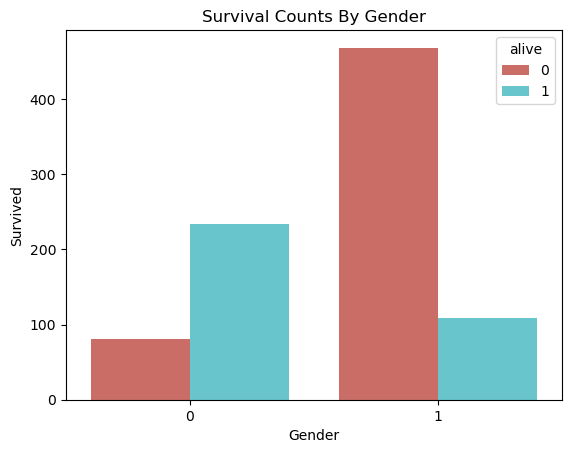

In [44]:

sns.countplot(
    x='sex_male',
    hue='alive',
    data=df,
    palette='hls'
    )
plt.title('Survival Counts By Gender')
plt.xlabel('Gender')
plt.ylabel('Survived')

Text(0, 0.5, 'Survival Rate')

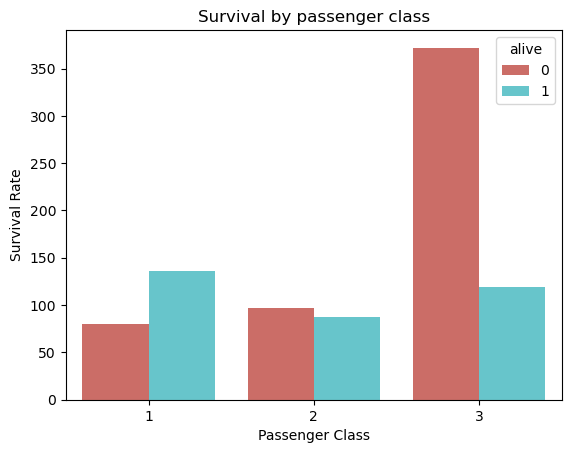

In [45]:
sns.countplot(
    x='pclass',
    hue='alive',
    data=df,
    palette='hls'
)
plt.title('Survival by passenger class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

Text(0, 0.5, 'Survival Rate')

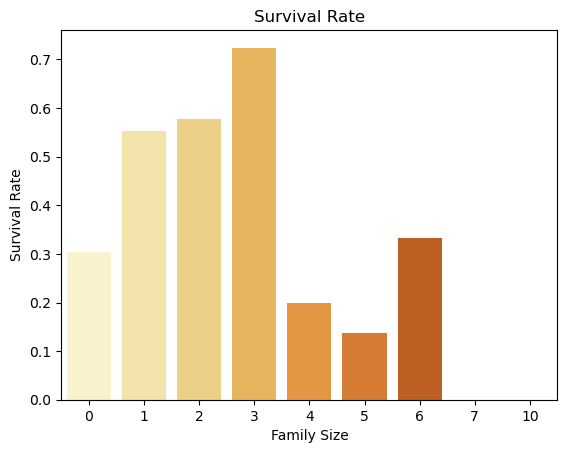

In [46]:
survivalByFamilySize =df.groupby('family_size')['alive'].mean()
sns.barplot(
    x=survivalByFamilySize.index,
    y=survivalByFamilySize.values,
    palette='YlOrBr'
)
plt.title('Survival Rate')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')

Text(0, 0.5, 'Number Of Passenger')

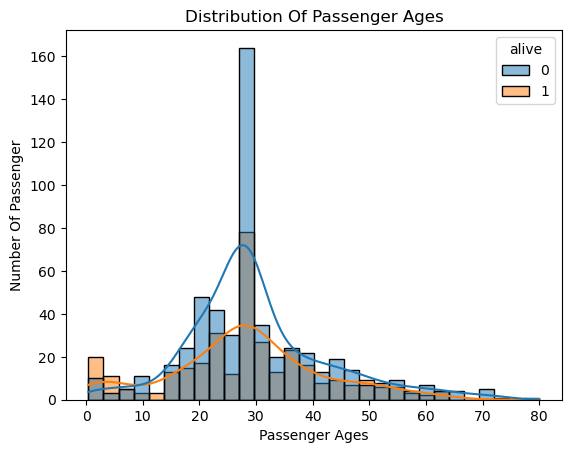

In [47]:
sns.histplot(
    x='age',
    hue='alive',
    kde=True,
    data=df
)
plt.title('Distribution Of Passenger Ages')
plt.xlabel('Passenger Ages')
plt.ylabel('Number Of Passenger')

Text(0.5, 1.0, 'Correlation Matrix')

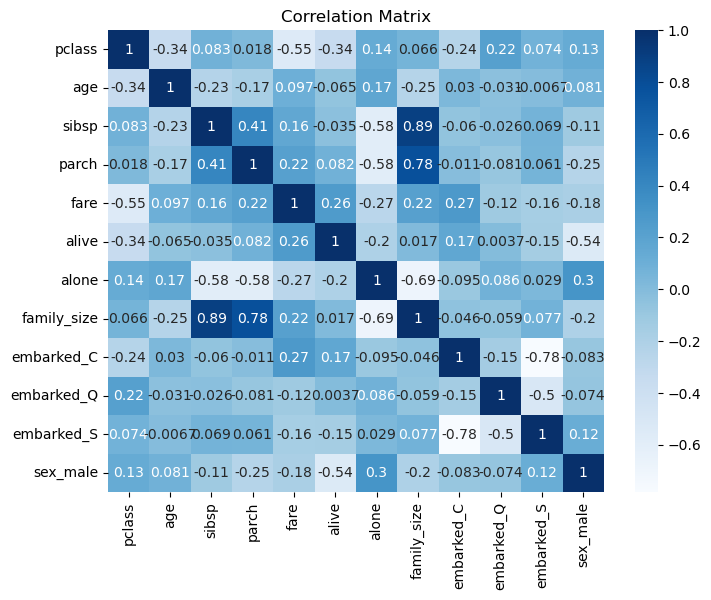

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='Blues'
)
plt.title('Correlation Matrix')

## Train/Test Split

In [49]:
X=df.drop('alive',axis=1)
y=df['alive']

In [50]:
X_train , X_test , y_train,y_test = train_test_split (X,y,train_size=0.80 , random_state=42)

## Scaling

In [51]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

In [52]:
model=KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto')

In [53]:
model.fit(X_train , y_train)

KNeighborsClassifier()

In [54]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

## Evaluation

In [55]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       444
           1       0.85      0.75      0.80       268

    accuracy                           0.86       712
   macro avg       0.85      0.83      0.84       712
weighted avg       0.85      0.86      0.85       712



In [56]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [57]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

train_accuracy ,test_accuracy

(0.8553370786516854, 0.8044692737430168)

## Confusion Matrix

Text(50.722222222222214, 0.5, 'Actual')

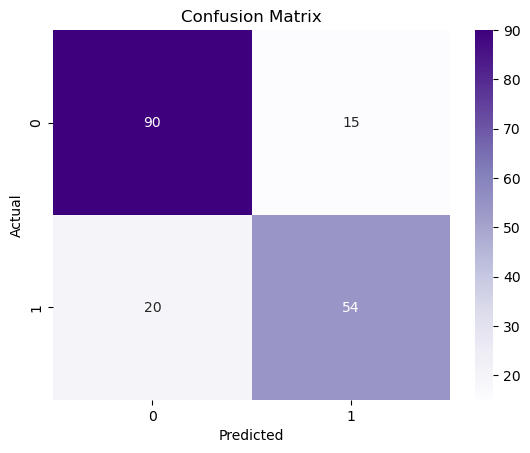

In [58]:
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual') 